In [17]:
# Data processing and visualization
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap

# Sampling Techniques
from imblearn.over_sampling import ADASYN, RandomOverSampler, SMOTE

# Models
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from xgboost import XGBClassifier, plot_importance

# Preprocessing & Splitting
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Metrics
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)

# System & Utilities
import os
import joblib

In [18]:
#Load the featured dataset we built in the Data_Preparation Notebook
df = pd.read_csv('../data/gym_churn_featured.csv')

In [19]:
#Cleaning data: Removing columns that are not required in the ML model

y = df['Churn']

columns_to_drop = ['Name', 'Email', 'Phone_Number', 'Churn']
X = df.drop(columns=columns_to_drop, errors='ignore')

print(f"Dataset now contains {len(X.columns)} purely mathematical columns.")

display(X.head(5))

Dataset now contains 16 purely mathematical columns.


,gender,Near_Location,Partner,Promo_friends,Phone,Contract_period,Group_visits,Age,Avg_additional_charges_total,Month_to_end_contract,Lifetime,Avg_class_frequency_total,Avg_class_frequency_current_month,Attendance_Drop,Months_Served,Age_at_Joining
0,1,1,1,1,0,6,1,29,14.227470,5.0,3,0.020398,0.000000,0.020398,1.0,28.8
1,0,1,0,0,1,12,1,31,113.202938,12.0,7,1.922936,1.910244,0.012693,0.0,30.4
2,0,1,1,0,1,1,0,28,129.448479,1.0,2,1.859098,1.736502,0.122596,0.0,27.8
3,0,1,1,1,1,12,1,33,62.669863,12.0,2,3.205633,3.357215,-0.151582,0.0,32.8
4,1,1,1,1,1,1,0,26,198.362265,1.0,3,1.113884,1.120078,-0.006194,0.0,25.8


In [20]:
#Data preparation for ML training

# Target & features (drop non-predictive columns)
y = df['Churn'].astype(int)
X = df.drop(columns=['Name', 'Email', 'Phone_Number', 'Churn'], errors='ignore')

# Split first, balance later — always!
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Scale
scaler  = StandardScaler()
X_train = scaler.fit_transform(X_train_raw)
X_test  = scaler.transform(X_test_raw)

feature_names = X.columns.tolist()

In [21]:
#Sampling methods and models
samplers = {
    'Random Oversampling' : RandomOverSampler(random_state=42),
    'SMOTE'               : SMOTE(random_state=42),
    'ADASYN'              : ADASYN(random_state=42),
}

models = {
    'Logistic Regression' : LogisticRegression(max_iter=1000, random_state=42),
    'SVM'                 : SVC(probability=True, random_state=42),
    'Random Forest'       : RandomForestClassifier(random_state=42),
    'XGBoost'             : XGBClassifier(eval_metric='logloss', random_state=42),
}

In [22]:
#Training Loop
results_v2 = []

for sampler_name, sampler in samplers.items():
    print(f"  Applying {sampler_name}...")
    X_res, y_res = sampler.fit_resample(X_train, y_train)

    for model_name, model in models.items():
        model.fit(X_res, y_res)

        y_pred       = model.predict(X_test)
        y_pred_proba = model.predict_proba(X_test)[:, 1]

        results_v2.append({
            'Balancing Technique' : sampler_name,
            'Algorithm'           : model_name,
            'Accuracy'            : round(accuracy_score(y_test, y_pred),       4),
            'Precision'           : round(precision_score(y_test, y_pred),      4),
            'Recall'              : round(recall_score(y_test, y_pred),         4),
            'F1-Score'            : round(f1_score(y_test, y_pred),             4),
            'AUC'                 : round(roc_auc_score(y_test, y_pred_proba),  4),
        })

  Applying Random Oversampling...
  Applying SMOTE...
  Applying ADASYN...


In [23]:
#Leaderboard
leaderboard_v2 = (
    pd.DataFrame(results_v2)
      .sort_values(by='AUC', ascending=False)
      .reset_index(drop=True)
)

print("\nWhich combination performed better!")
display(leaderboard_v2)


Which combination performed better!


,Balancing Technique,Algorithm,Accuracy,Precision,Recall,F1-Score,AUC
0,Random Oversampling,XGBoost,0.9450,0.9072,0.8713,0.8889,0.9846
1,SMOTE,XGBoost,0.9437,0.8945,0.8812,0.8878,0.9817
2,ADASYN,XGBoost,0.9387,0.8768,0.8812,0.8790,0.9806
3,Random Oversampling,SVM,0.9337,0.8565,0.8861,0.8710,0.9774
4,SMOTE,SVM,0.9337,0.8634,0.8762,0.8698,0.9764
5,ADASYN,SVM,0.9287,0.8251,0.9109,0.8659,0.9762
6,Random Oversampling,Random Forest,0.9437,0.9067,0.8663,0.8861,0.9761
7,ADASYN,Random Forest,0.9375,0.8725,0.8812,0.8768,0.9734
8,SMOTE,Random Forest,0.9437,0.9067,0.8663,0.8861,0.9720
9,SMOTE,Logistic Regression,0.9113,0.7937,0.8762,0.8329,0.9699


In [24]:
#_______ Random Oversampling + XGBoost __________#

# 1. Applying random oversampling and naming columns for plot importance
print("Applying Random Oversampling (ROS)")
ros = RandomOverSampler(random_state=42)
orig_size = len(y_train)

X_train_ros, y_train_ros = ros.fit_resample(X_train, y_train)
new_size = len(y_train_ros)

print(f"  Original training rows : {orig_size}")
print(f"  After ROS rows         : {new_size}")
print(f"  Synthetic rows added   : {new_size - orig_size}")

X_train_ros = pd.DataFrame(X_train_ros, columns=feature_names)
X_test       = pd.DataFrame(X_test,      columns=feature_names)

Applying Random Oversampling (ROS)
  Original training rows : 3200
  After ROS rows         : 4682
  Synthetic rows added   : 1482


In [25]:
#Training XGBoost
print("Training XGBoost...")

model = XGBClassifier(eval_metric='logloss', random_state=42)
model.fit(X_train_ros, y_train_ros)

y_pred       = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1]

print(f"\nROC AUC Score: {roc_auc_score(y_test, y_pred_proba):.4f}")

# ROS + XGBOost Report Visualization
report_df = pd.DataFrame(classification_report(y_test, y_pred, output_dict=True)).transpose().round(2)
display(report_df)

Training XGBoost...

ROC AUC Score: 0.9846


,precision,recall,f1-score,support
0,0.96,0.97,0.96,598.00
1,0.91,0.87,0.89,202.00
accuracy,0.94,0.94,0.94,0.94
macro avg,0.93,0.92,0.93,800.00
weighted avg,0.94,0.94,0.94,800.00


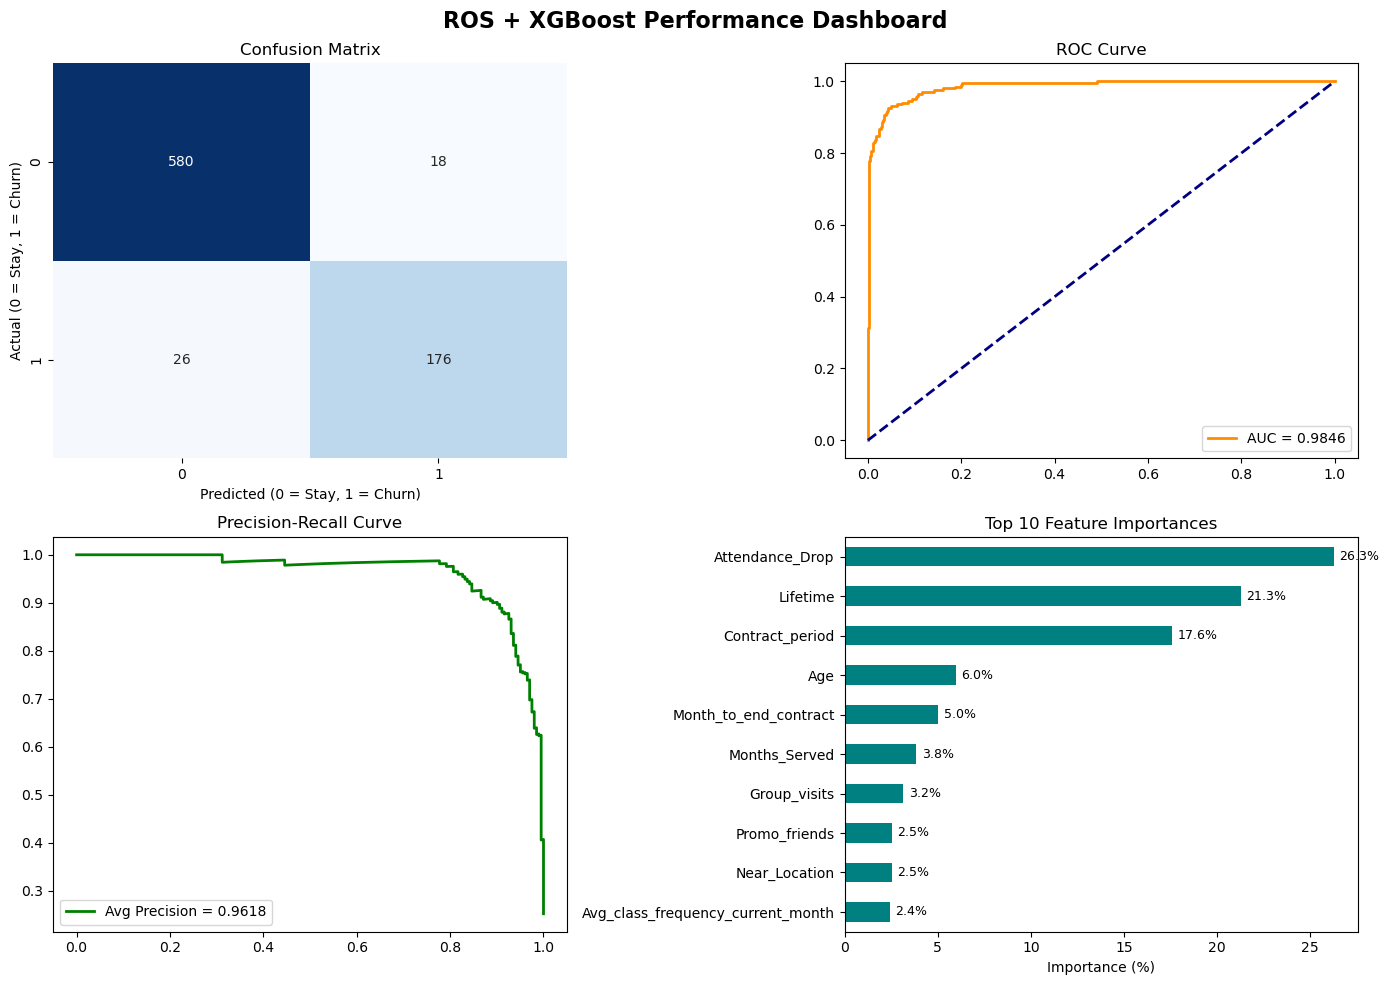

In [37]:
#Performance Visualization Of ROS + XGBoost Model
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('ROS + XGBoost Performance Dashboard', fontsize=16, fontweight='bold')

# A: Confusion Matrix
sns.heatmap(confusion_matrix(y_test, y_pred),
            annot=True, fmt='d', cmap='Blues', cbar=False, ax=axes[0, 0])
axes[0, 0].set_title('Confusion Matrix')
axes[0, 0].set_xlabel('Predicted (0 = Stay, 1 = Churn)')
axes[0, 0].set_ylabel('Actual (0 = Stay, 1 = Churn)')

# B: ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
auc_score = roc_auc_score(y_test, y_pred_proba)
axes[0, 1].plot(fpr, tpr, color='darkorange', lw=2, label=f'AUC = {auc_score:.4f}')
axes[0, 1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
axes[0, 1].set_title('ROC Curve')
axes[0, 1].legend(loc='lower right')

# C: Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_test, y_pred_proba)
ap_score = average_precision_score(y_test, y_pred_proba)
axes[1, 0].plot(recall, precision, color='green', lw=2, label=f'Avg Precision = {ap_score:.4f}')
axes[1, 0].set_title('Precision-Recall Curve')
axes[1, 0].legend(loc='lower left')

# D: Feature Importance
importances = pd.Series(model.feature_importances_ * 100, index=feature_names)
importances = importances.sort_values(ascending=True).tail(10)

importances.plot(kind='barh', ax=axes[1, 1], color='teal')
axes[1, 1].set_title('Top 10 Feature Importances')
axes[1, 1].set_xlabel('Importance (%)')
for i, v in enumerate(importances):
    axes[1, 1].text(v + 0.3, i, f'{v:.1f}%', va='center', fontsize=9)

plt.tight_layout()
plt.show()

SHAP Analysis


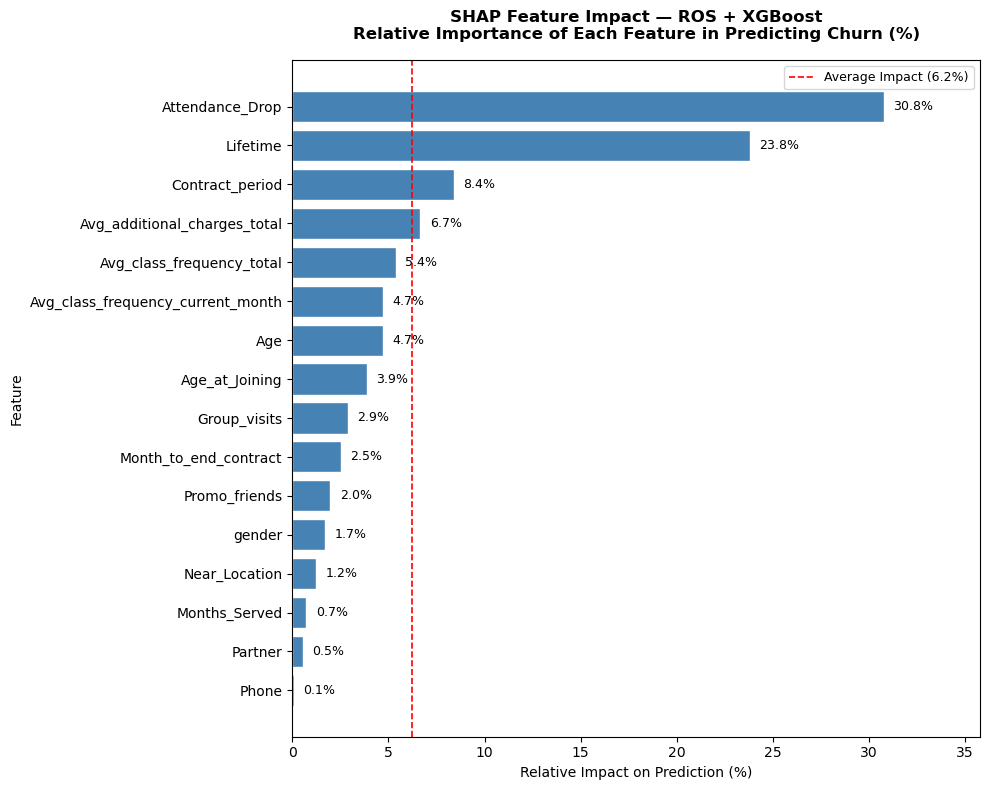

In [40]:
# SHAP Visualization - ROS
print("SHAP Analysis")

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

# CONVERT TO PERCENTAGES
raw_importance = pd.Series(np.abs(shap_values).mean(axis=0), index=feature_names)
shap_percentage = (raw_importance / raw_importance.sum()) * 100
shap_percentage = shap_percentage.sort_values(ascending=True)

# GRAPH
fig, ax = plt.subplots(figsize=(10, 8))
bars = ax.barh(shap_percentage.index, shap_percentage.values, color='steelblue', edgecolor='white')

# percentage labels
for bar, val in zip(bars, shap_percentage.values):
    ax.text(val + 0.5, bar.get_y() + bar.get_height() / 2, f'{val:.1f}%', va='center', fontsize=9, color='black')

ax.set_title('SHAP Feature Impact — ROS + XGBoost\n'
             'Relative Importance of Each Feature in Predicting Churn (%)',
             fontsize=12, fontweight='bold', pad=15)
ax.set_xlabel('Relative Impact on Prediction (%)', fontsize=10)
ax.set_ylabel('Feature', fontsize=10)

# Average Line
avg_pct = 100 / len(shap_percentage)
ax.axvline(x=avg_pct, color='red', linestyle='--', linewidth=1.2,
           label=f'Average Impact ({avg_pct:.1f}%)')
ax.legend(fontsize=9)
plt.xlim(0, shap_percentage.max() + 5)

plt.tight_layout()
plt.show()

In [28]:
#_______ SMOTE + XGBoost __________#

#Applying SMOTE
print("Applying SMOTE")

smote = SMOTE(random_state=42)
orig_size = len(y_train)

X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)
new_size = len(y_train_smote)

print(f"  Original training rows : {orig_size}")
print(f"  After SMOTE rows       : {new_size}")
print(f"  Synthetic rows added   : {new_size - orig_size}")

X_train_smote = pd.DataFrame(X_train_smote, columns=feature_names)

Applying SMOTE
  Original training rows : 3200
  After SMOTE rows       : 4682
  Synthetic rows added   : 1482


In [29]:
#Training XGBoost
print("Training XGBoost")

model_smote = XGBClassifier(eval_metric='logloss', random_state=42)
model_smote.fit(X_train_smote, y_train_smote)

y_pred_smote       = model_smote.predict(X_test)
y_pred_proba_smote = model_smote.predict_proba(X_test)[:, 1]

print(f"\nROC AUC Score: {roc_auc_score(y_test, y_pred_proba_smote):.4f}")

report_df_smote = pd.DataFrame(
    classification_report(y_test, y_pred_smote, output_dict=True)
).transpose().round(2)
display(report_df_smote)

Training XGBoost

ROC AUC Score: 0.9817


,precision,recall,f1-score,support
0,0.96,0.96,0.96,598.00
1,0.89,0.88,0.89,202.00
accuracy,0.94,0.94,0.94,0.94
macro avg,0.93,0.92,0.93,800.00
weighted avg,0.94,0.94,0.94,800.00


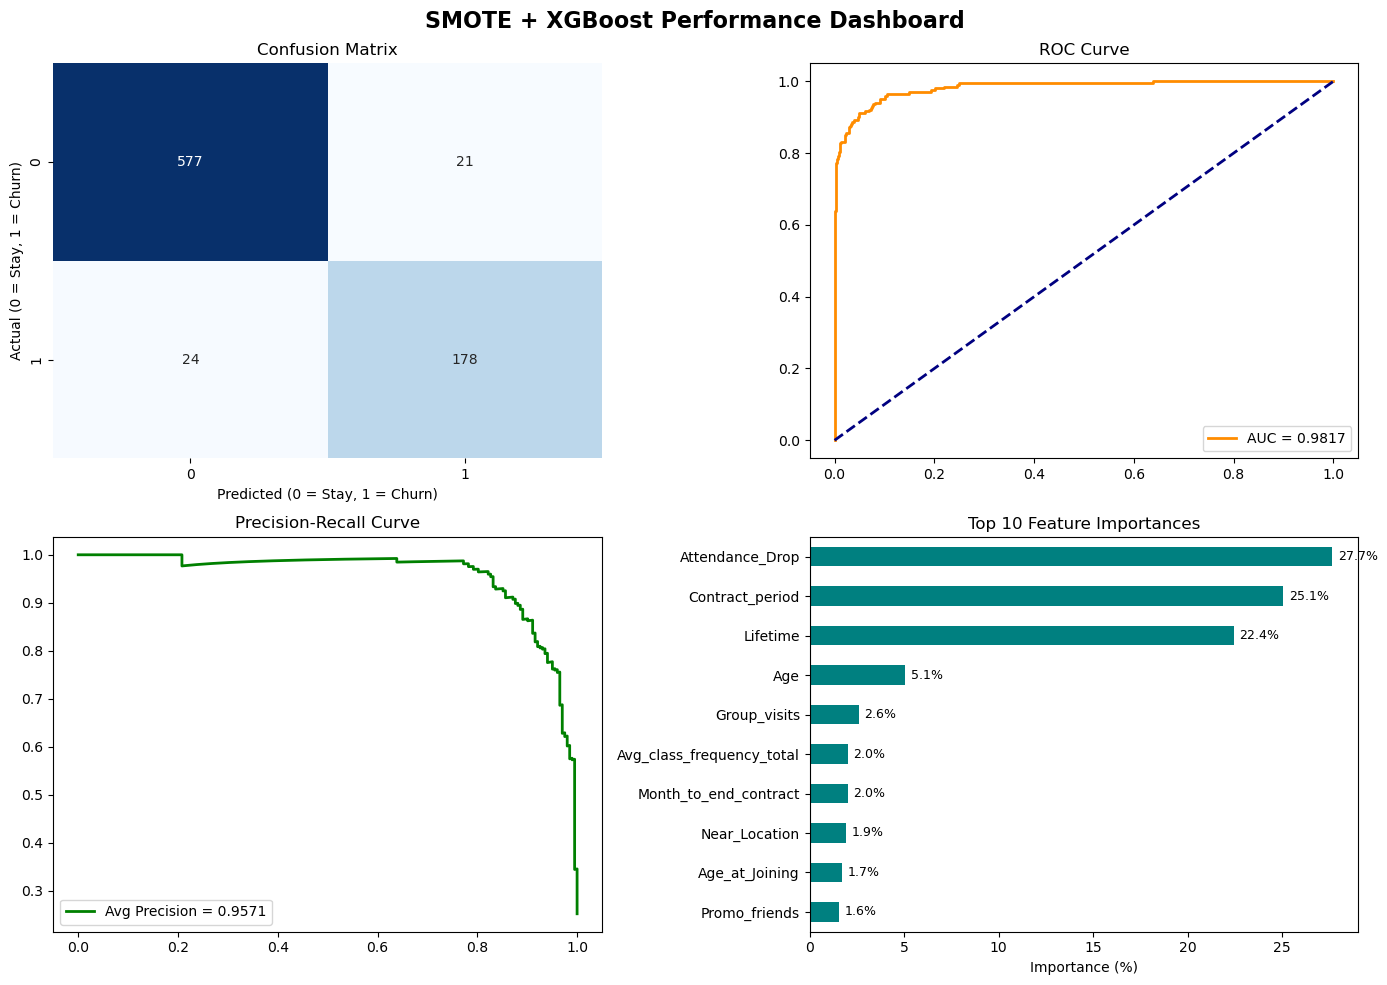

In [30]:
#Performance Visualization Of SMOTE + XGBoost Model
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('SMOTE + XGBoost Performance Dashboard', fontsize=16, fontweight='bold')

# A: Confusion Matrix
sns.heatmap(confusion_matrix(y_test, y_pred_smote),
            annot=True, fmt='d', cmap='Blues', cbar=False, ax=axes[0, 0])
axes[0, 0].set_title('Confusion Matrix')
axes[0, 0].set_xlabel('Predicted (0 = Stay, 1 = Churn)')
axes[0, 0].set_ylabel('Actual (0 = Stay, 1 = Churn)')

# B: ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_pred_proba_smote)
auc_score_smote = roc_auc_score(y_test, y_pred_proba_smote)
axes[0, 1].plot(fpr, tpr, color='darkorange', lw=2, label=f'AUC = {auc_score_smote:.4f}')
axes[0, 1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
axes[0, 1].set_title('ROC Curve')
axes[0, 1].legend(loc='lower right')

# C: Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_test, y_pred_proba_smote)
ap_score_smote = average_precision_score(y_test, y_pred_proba_smote)
axes[1, 0].plot(recall, precision, color='green', lw=2, label=f'Avg Precision = {ap_score_smote:.4f}')
axes[1, 0].set_title('Precision-Recall Curve')
axes[1, 0].legend(loc='lower left')

# D: Feature Importance (%)
importances_smote = pd.Series(
    model_smote.feature_importances_ * 100, index=feature_names
).sort_values(ascending=True).tail(10)

importances_smote.plot(kind='barh', ax=axes[1, 1], color='teal')
axes[1, 1].set_title('Top 10 Feature Importances')
axes[1, 1].set_xlabel('Importance (%)')
for i, v in enumerate(importances_smote):
    axes[1, 1].text(v + 0.3, i, f'{v:.1f}%', va='center', fontsize=9)

plt.tight_layout()
plt.show()

SHAP Analysis: SMOTE


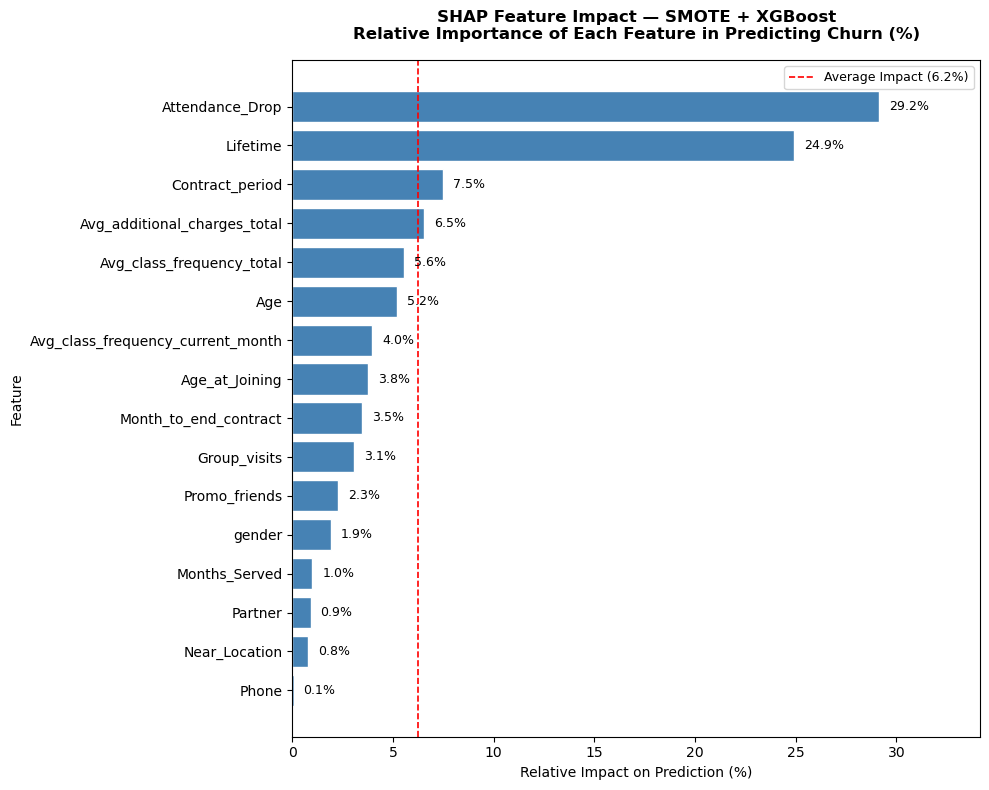

In [39]:
# SHAP Visualization - SMOTE
print("SHAP Analysis: SMOTE")

explainer_smote = shap.TreeExplainer(model_smote)
shap_values_smote = explainer_smote.shap_values(X_test)

# Percentages
raw_importance_smote = pd.Series(np.abs(shap_values_smote).mean(axis=0), index=feature_names)
shap_percentage_smote = (raw_importance_smote / raw_importance_smote.sum()) * 100
shap_percentage_smote = shap_percentage_smote.sort_values(ascending=True)

# Plot
fig, ax = plt.subplots(figsize=(10, 8))
bars = ax.barh(shap_percentage_smote.index, shap_percentage_smote.values, color='steelblue', edgecolor='white')

for bar, val in zip(bars, shap_percentage_smote.values):
    ax.text(val + 0.5, bar.get_y() + bar.get_height() / 2,
            f'{val:.1f}%', va='center', fontsize=9, color='black')

ax.set_title('SHAP Feature Impact — SMOTE + XGBoost\n'
             'Relative Importance of Each Feature in Predicting Churn (%)', 
             fontsize=12, fontweight='bold', pad=15)
ax.set_xlabel('Relative Impact on Prediction (%)', fontsize=10)
ax.set_ylabel('Feature', fontsize=10)

#Average line
avg_pct_smote = 100 / len(shap_percentage_smote)
ax.axvline(x=avg_pct_smote, color='red', linestyle='--',
           linewidth=1.2, label=f'Average Impact ({avg_pct_smote:.1f}%)')
ax.legend(fontsize=9)

plt.xlim(0, shap_percentage_smote.max() + 5)
plt.tight_layout()
plt.show()

In [32]:
#_______ ADASYN + XGBoost __________#

#Applying ADASYN
print("Applying ADASYN")

adasyn = ADASYN(random_state=42)
orig_size = len(y_train)

X_train_adasyn, y_train_adasyn = adasyn.fit_resample(X_train, y_train)
new_size = len(y_train_adasyn)

print(f"  Original training rows : {orig_size}")
print(f"  After ADASYN rows      : {new_size}")
print(f"  Synthetic rows added   : {new_size - orig_size}")

X_train_adasyn = pd.DataFrame(X_train_adasyn, columns=feature_names)

Applying ADASYN
  Original training rows : 3200
  After ADASYN rows      : 4766
  Synthetic rows added   : 1566


In [33]:
#Training XGBoost
print("Training XGBoost")

model_adasyn = XGBClassifier(eval_metric='logloss', random_state=42)
model_adasyn.fit(X_train_adasyn, y_train_adasyn)

y_pred_adasyn       = model_adasyn.predict(X_test)
y_pred_proba_adasyn = model_adasyn.predict_proba(X_test)[:, 1]

print(f"\nROC AUC Score: {roc_auc_score(y_test, y_pred_proba_adasyn):.4f}")

report_df_adasyn = pd.DataFrame(
    classification_report(y_test, y_pred_adasyn, output_dict=True)
).transpose().round(2)
display(report_df_adasyn)

Training XGBoost

ROC AUC Score: 0.9806


,precision,recall,f1-score,support
0,0.96,0.96,0.96,598.00
1,0.88,0.88,0.88,202.00
accuracy,0.94,0.94,0.94,0.94
macro avg,0.92,0.92,0.92,800.00
weighted avg,0.94,0.94,0.94,800.00


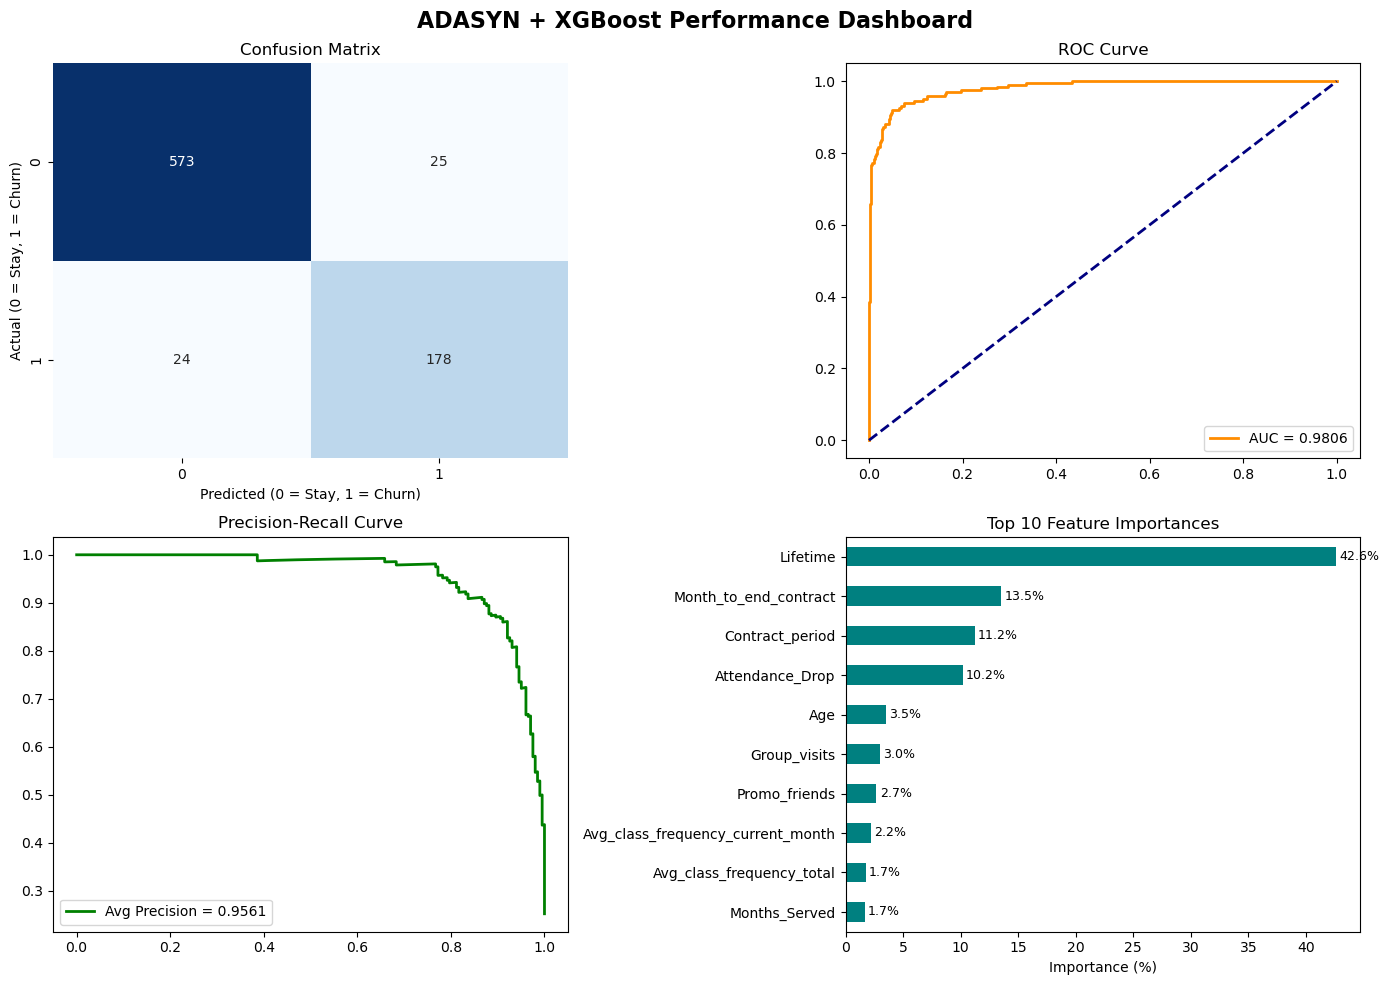

In [34]:
#Performance Visualization Of ADASYN + XGBoost Model
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('ADASYN + XGBoost Performance Dashboard', fontsize=16, fontweight='bold')

# A: Confusion Matrix
sns.heatmap(confusion_matrix(y_test, y_pred_adasyn),
            annot=True, fmt='d', cmap='Blues', cbar=False, ax=axes[0, 0])
axes[0, 0].set_title('Confusion Matrix')
axes[0, 0].set_xlabel('Predicted (0 = Stay, 1 = Churn)')
axes[0, 0].set_ylabel('Actual (0 = Stay, 1 = Churn)')

# B: ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_pred_proba_adasyn)
auc_score_adasyn = roc_auc_score(y_test, y_pred_proba_adasyn)
axes[0, 1].plot(fpr, tpr, color='darkorange', lw=2, label=f'AUC = {auc_score_adasyn:.4f}')
axes[0, 1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
axes[0, 1].set_title('ROC Curve')
axes[0, 1].legend(loc='lower right')

# C: Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_test, y_pred_proba_adasyn)
ap_score_adasyn = average_precision_score(y_test, y_pred_proba_adasyn)
axes[1, 0].plot(recall, precision, color='green', lw=2, label=f'Avg Precision = {ap_score_adasyn:.4f}')
axes[1, 0].set_title('Precision-Recall Curve')
axes[1, 0].legend(loc='lower left')

# D: Feature Importance (%)
importances_adasyn = pd.Series(
    model_adasyn.feature_importances_ * 100, index=feature_names
).sort_values(ascending=True).tail(10)

importances_adasyn.plot(kind='barh', ax=axes[1, 1], color='teal')
axes[1, 1].set_title('Top 10 Feature Importances')
axes[1, 1].set_xlabel('Importance (%)')
for i, v in enumerate(importances_adasyn):
    axes[1, 1].text(v + 0.3, i, f'{v:.1f}%', va='center', fontsize=9)

plt.tight_layout()
plt.show()

SHAP Analysis: ADASYN


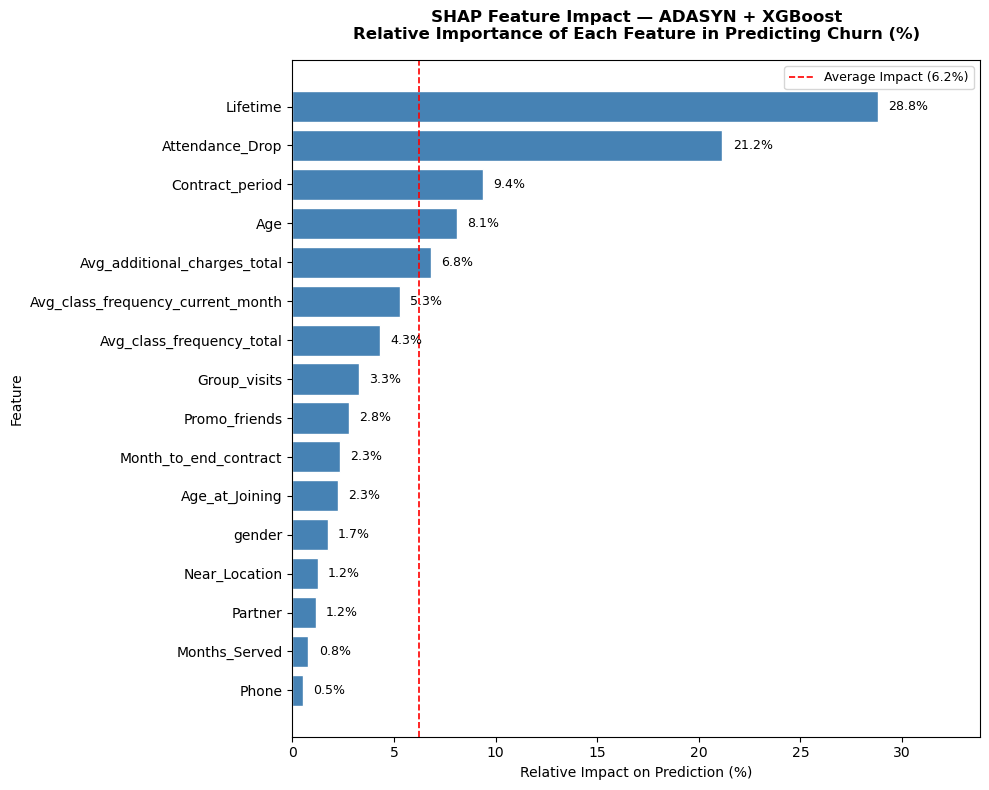

In [41]:
# SHAP Visualization - ADASYN
print("SHAP Analysis: ADASYN")

explainer_adasyn = shap.TreeExplainer(model_adasyn)
shap_values_adasyn = explainer_adasyn.shap_values(X_test)

# Percentages
raw_importance_adasyn = pd.Series(np.abs(shap_values_adasyn).mean(axis=0), index=feature_names)
shap_percentage_adasyn = (raw_importance_adasyn / raw_importance_adasyn.sum()) * 100
shap_percentage_adasyn = shap_percentage_adasyn.sort_values(ascending=True)

# Plot
fig, ax = plt.subplots(figsize=(10, 8))
bars = ax.barh(shap_percentage_adasyn.index, shap_percentage_adasyn.values, color='steelblue', edgecolor='white')

for bar, val in zip(bars, shap_percentage_adasyn.values):
    ax.text(val + 0.5, bar.get_y() + bar.get_height() / 2,
            f'{val:.1f}%', va='center', fontsize=9, color='black')

ax.set_title('SHAP Feature Impact — ADASYN + XGBoost\n'
             'Relative Importance of Each Feature in Predicting Churn (%)',
             fontsize=12, fontweight='bold', pad=15)
ax.set_xlabel('Relative Impact on Prediction (%)', fontsize=10)
ax.set_ylabel('Feature', fontsize=10)

#Average line
avg_pct_adasyn = 100 / len(shap_percentage_adasyn)
ax.axvline(x=avg_pct_adasyn, color='red', linestyle='--',
           linewidth=1.2, label=f'Average Impact ({avg_pct_adasyn:.1f}%)')
ax.legend(fontsize=9)

plt.xlim(0, shap_percentage_adasyn.max() + 5)
plt.tight_layout()
plt.show()

In [42]:
#Export Models
print("Saving all models to ../app folder")

if not os.path.exists('../app'):
    os.makedirs('../app')

joblib.dump(model,'../app/xgb_ros.pkl')
joblib.dump(model_smote,'../app/xgb_smote.pkl')
joblib.dump(model_adasyn,'../app/xgb_adasyn.pkl')
joblib.dump(scaler, '../app/scaler.pkl')

print("All models and scaler saved to /app!")

Saving all models to ../app folder
All models and scaler saved to /app!
